In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

c:\Users\yhk25\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Counts of Job Titles

In [2]:
df.pivot_table(index = 'job_title_short', aggfunc = 'size')

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
dtype: int64

In [5]:
df.groupby('job_title_short').size()

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
dtype: int64

In [6]:
df.pivot_table(values = 'salary_year_avg', index = 'job_title_short', aggfunc = 'median')

,salary_year_avg
job_title_short,
Business Analyst,85000.0
Cloud Engineer,90000.0
Data Analyst,90000.0
Data Engineer,125000.0
Data Scientist,127500.0
Machine Learning Engineer,106415.0
Senior Data Analyst,111175.0
Senior Data Engineer,147500.0
Senior Data Scientist,155500.0


In [7]:
df.groupby('job_title_short')['salary_year_avg'].median()

job_title_short
Business Analyst              85000.0
Cloud Engineer                90000.0
Data Analyst                  90000.0
Data Engineer                125000.0
Data Scientist               127500.0
Machine Learning Engineer    106415.0
Senior Data Analyst          111175.0
Senior Data Engineer         147500.0
Senior Data Scientist        155500.0
Software Engineer             99150.0
Name: salary_year_avg, dtype: float64

In [9]:
df.pivot_table(values = 'salary_year_avg', index = 'job_title_short', columns = 'job_country', aggfunc = 'median')

job_country,Albania,Algeria,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahamas,Bangladesh,Belarus,...,Uganda,Ukraine,United Arab Emirates,United Kingdom,United States,Uruguay,Uzbekistan,Vietnam,Zambia,Zimbabwe
job_title_short,,,,,,,,,,,,,,,,,,,,,
Business Analyst,NaN,NaN,71100.00,NaN,70000.0,NaN,NaN,NaN,16500.0,NaN,...,NaN,72900.0,NaN,56700.0,90000.0,NaN,NaN,79200.0,NaN,NaN
Cloud Engineer,NaN,NaN,197500.00,NaN,110000.0,NaN,NaN,NaN,NaN,NaN,...,NaN,89100.0,NaN,NaN,116100.0,NaN,NaN,NaN,NaN,NaN
Data Analyst,49950.00,44100.0,92771.75,100500.0,109500.0,80850.00,NaN,NaN,NaN,400000.0,...,69300.0,72900.0,98500.0,87750.0,90000.0,100500.0,NaN,75550.0,NaN,63000.0
Data Engineer,NaN,45000.0,96773.00,48750.0,106712.5,147500.00,NaN,211000.0,97444.0,NaN,...,NaN,89100.0,97528.0,110000.0,125000.0,NaN,NaN,96773.0,NaN,NaN
Data Scientist,69981.25,NaN,71000.00,NaN,139216.0,71249.75,NaN,NaN,NaN,NaN,...,84200.0,131846.5,166419.5,105300.0,130000.0,NaN,30750.0,70000.0,90670.0,69085.0
Machine Learning Engineer,NaN,NaN,101029.00,87021.0,101029.0,89100.00,NaN,228750.0,69000.0,NaN,...,NaN,89100.0,62850.0,149653.0,150000.0,50000.0,NaN,57600.0,NaN,NaN
Senior Data Analyst,NaN,NaN,NaN,NaN,50640.0,89100.00,NaN,NaN,NaN,NaN,...,NaN,NaN,105837.5,111175.0,110000.0,NaN,NaN,105837.5,NaN,NaN
Senior Data Engineer,NaN,NaN,147500.00,NaN,147500.0,147500.00,NaN,173500.0,NaN,NaN,...,NaN,96773.0,NaN,147500.0,150000.0,NaN,NaN,147500.0,NaN,NaN
Senior Data Scientist,157500.00,NaN,NaN,NaN,157500.0,80850.00,NaN,NaN,NaN,NaN,...,NaN,157500.0,72000.0,157500.0,155000.0,57500.0,NaN,79200.0,NaN,NaN


In [17]:
top_countries = df['job_country'].value_counts().head(6).index

df_job_country_salary = df.pivot_table(
    values = 'salary_year_avg',
    index = 'job_country',
    columns = 'job_title_short',
    aggfunc = 'median'
)

df_job_country_salary = df_job_country_salary.loc[top_countries]

job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_job_country_salary = df_job_country_salary[job_titles]

df_job_country_salary

job_title_short,Data Analyst,Data Engineer,Data Scientist
job_country,,,
United States,90000.0,125000.0,130000.0
India,100500.0,147500.0,114008.0
United Kingdom,87750.0,110000.0,105300.0
France,69175.0,98301.5,88128.0
Germany,103750.0,147500.0,131560.0
Spain,91977.0,133000.0,88128.0


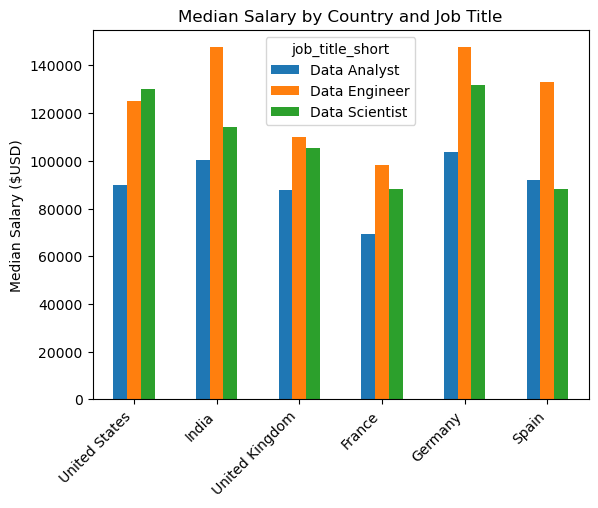

In [22]:
df_job_country_salary.plot(kind='bar')
plt.ylabel('Median Salary ($USD)')
plt.xlabel('')
plt.title('Median Salary by Country and Job Title')  
plt.xticks(rotation=45, ha='right')
plt.show()

In [23]:
df.groupby(['job_country', 'job_title_short'])['salary_year_avg'].agg(['max', 'median', 'min']).dropna()

max     median       min
job_country job_title_short                                     
Albania     Data Analyst            56700.0   49950.00   43200.0
            Data Scientist          70000.0   69981.25   69962.5
            Senior Data Scientist  157500.0  157500.00  157500.0
Algeria     Data Analyst            44100.0   44100.00   44100.0
            Data Engineer           45000.0   45000.00   45000.0
...                                     ...        ...       ...
Vietnam     Senior Data Scientist   79200.0   79200.00   79200.0
            Software Engineer       79200.0   53600.00   28000.0
Zambia      Data Scientist          90670.0   90670.00   90670.0
Zimbabwe    Data Analyst            63000.0   63000.00   63000.0
            Data Scientist          90670.0   69085.00   47500.0

[598 rows x 3 columns]

In [26]:
df.pivot_table(
    values='salary_year_avg',
    index = ['job_country', 'job_title_short'],
    aggfunc = {'salary_year_avg': ['min', 'max', 'median']}
)

max     median       min
job_country job_title_short                                     
Albania     Data Analyst            56700.0   49950.00   43200.0
            Data Scientist          70000.0   69981.25   69962.5
            Senior Data Scientist  157500.0  157500.00  157500.0
Algeria     Data Analyst            44100.0   44100.00   44100.0
            Data Engineer           45000.0   45000.00   45000.0
...                                     ...        ...       ...
Vietnam     Senior Data Scientist   79200.0   79200.00   79200.0
            Software Engineer       79200.0   53600.00   28000.0
Zambia      Data Scientist          90670.0   90670.00   90670.0
Zimbabwe    Data Analyst            63000.0   63000.00   63000.0
            Data Scientist          90670.0   69085.00   47500.0

[598 rows x 3 columns]

In [28]:
df.pivot_table(
    values = 'salary_year_avg',
    index = 'job_country',
    columns = 'job_title_short',
    aggfunc= 'median'
)

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
Albania,NaN,NaN,49950.00,NaN,69981.25,NaN,NaN,NaN,157500.0,NaN
Algeria,NaN,NaN,44100.00,45000.0,NaN,NaN,NaN,NaN,NaN,NaN
Argentina,71100.0,197500.0,92771.75,96773.0,71000.00,101029.0,NaN,147500.0,NaN,174500.0
Armenia,NaN,NaN,100500.00,48750.0,NaN,87021.0,NaN,NaN,NaN,NaN
Australia,70000.0,110000.0,109500.00,106712.5,139216.00,101029.0,50640.0,147500.0,157500.0,118350.0
...,...,...,...,...,...,...,...,...,...,...
Uruguay,NaN,NaN,100500.00,NaN,NaN,50000.0,NaN,NaN,57500.0,NaN
Uzbekistan,NaN,NaN,NaN,NaN,30750.00,NaN,NaN,NaN,NaN,NaN
Vietnam,79200.0,NaN,75550.00,96773.0,70000.00,57600.0,105837.5,147500.0,79200.0,53600.0


## Problem

In [30]:
df.pivot_table(
    index = 'job_title_short',
    columns = 'job_country',
    aggfunc = 'size'
)

job_country,Afghanistan,Albania,Algeria,Angola,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahamas,...,United Arab Emirates,United Kingdom,United States,Uruguay,Uzbekistan,Venezuela,Vietnam,Yemen,Zambia,Zimbabwe
job_title_short,,,,,,,,,,,,,,,,,,,,,
Business Analyst,4.0,11.0,21.0,1.0,453.0,29.0,928.0,738.0,16.0,5.0,...,984.0,827.0,7382.0,199.0,55.0,2.0,91.0,3.0,30.0,6.0
Cloud Engineer,NaN,1.0,5.0,NaN,322.0,4.0,489.0,266.0,NaN,2.0,...,93.0,193.0,423.0,53.0,3.0,2.0,70.0,NaN,4.0,3.0
Data Analyst,9.0,36.0,22.0,2.0,1273.0,33.0,1658.0,2169.0,21.0,7.0,...,2587.0,10482.0,67816.0,227.0,39.0,16.0,334.0,4.0,40.0,34.0
Data Engineer,NaN,30.0,21.0,3.0,2265.0,45.0,4658.0,2175.0,7.0,14.0,...,1139.0,11807.0,35080.0,248.0,49.0,19.0,768.0,2.0,5.0,11.0
Data Scientist,1.0,12.0,27.0,1.0,1617.0,28.0,1179.0,1709.0,16.0,5.0,...,1360.0,9148.0,58830.0,140.0,50.0,9.0,375.0,NaN,13.0,13.0
Machine Learning Engineer,NaN,4.0,2.0,NaN,287.0,22.0,360.0,305.0,2.0,3.0,...,164.0,317.0,921.0,46.0,22.0,4.0,115.0,NaN,2.0,1.0
Senior Data Analyst,2.0,2.0,NaN,NaN,255.0,22.0,310.0,301.0,2.0,1.0,...,262.0,1356.0,11791.0,50.0,15.0,4.0,71.0,NaN,5.0,1.0
Senior Data Engineer,NaN,6.0,1.0,NaN,647.0,57.0,1482.0,542.0,4.0,12.0,...,227.0,3337.0,9289.0,106.0,54.0,4.0,220.0,NaN,NaN,3.0
Senior Data Scientist,NaN,11.0,NaN,1.0,350.0,16.0,302.0,451.0,1.0,1.0,...,245.0,2367.0,12946.0,54.0,19.0,3.0,91.0,NaN,2.0,1.0


In [32]:
df.pivot_table(
    values='salary_year_avg',
    index='job_title_short',
    aggfunc=['min', 'median', 'max']
)

,min,median,max
,salary_year_avg,salary_year_avg,salary_year_avg
job_title_short,,,
Business Analyst,16500.0,85000.0,387460.0
Cloud Engineer,42000.0,90000.0,280000.0
Data Analyst,25000.0,90000.0,650000.0
Data Engineer,15000.0,125000.0,525000.0
Data Scientist,27000.0,127500.0,960000.0
Machine Learning Engineer,30000.0,106415.0,325000.0
Senior Data Analyst,30000.0,111175.0,425000.0
Senior Data Engineer,35000.0,147500.0,425000.0


In [33]:
df.pivot_table(
    values = 'salary_year_avg',
    index = 'job_title_short',
    columns = 'job_country',
    aggfunc = 'sum'
)

job_country,Afghanistan,Albania,Algeria,Angola,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahamas,...,United Arab Emirates,United Kingdom,United States,Uruguay,Uzbekistan,Venezuela,Vietnam,Yemen,Zambia,Zimbabwe
job_title_short,,,,,,,,,,,,,,,,,,,,,
Business Analyst,0.0,0.0,0.0,0.0,142200.0,0.0,263000.0,0.0,0.0,0.0,...,0.0,247800.0,4.145162e+07,0.0,0.0,0.0,223200.0,0.0,0.0,0.0
Cloud Engineer,NaN,0.0,0.0,NaN,197500.0,0.0,110000.0,0.0,NaN,0.0,...,0.0,0.0,2.401818e+06,0.0,0.0,0.0,0.0,NaN,0.0,0.0
Data Analyst,0.0,99900.0,44100.0,0.0,341745.5,201000.0,411500.0,378496.0,0.0,0.0,...,459375.0,6437586.0,4.113097e+08,100500.0,0.0,0.0,999267.0,0.0,0.0,63000.0
Data Engineer,NaN,0.0,45000.0,0.0,1225599.0,97500.0,3374399.5,405000.0,0.0,1755244.0,...,752992.5,6937332.0,3.912708e+08,0.0,0.0,0.0,1576131.0,0.0,0.0,0.0
Data Scientist,0.0,139962.5,0.0,0.0,597221.5,0.0,978291.0,142499.5,0.0,0.0,...,166419.5,8268820.0,6.371774e+08,0.0,30750.0,0.0,534400.0,NaN,90670.0,138170.0
Machine Learning Engineer,NaN,0.0,0.0,NaN,393029.0,174042.0,856129.0,178200.0,0.0,457500.0,...,125700.0,976951.0,1.974277e+07,50000.0,0.0,0.0,571050.0,NaN,0.0,0.0
Senior Data Analyst,0.0,0.0,NaN,NaN,0.0,0.0,101280.0,178200.0,0.0,0.0,...,421350.0,858515.0,1.056607e+08,0.0,0.0,0.0,402050.0,NaN,0.0,0.0
Senior Data Engineer,NaN,0.0,0.0,NaN,295000.0,0.0,1079046.0,531600.0,0.0,1287500.0,...,0.0,3301200.5,1.602320e+08,0.0,0.0,0.0,508500.0,NaN,NaN,0.0
Senior Data Scientist,NaN,157500.0,NaN,0.0,0.0,0.0,787500.0,80850.0,0.0,0.0,...,216000.0,4011376.0,1.977291e+08,57500.0,0.0,0.0,79200.0,NaN,0.0,0.0
